<a href="https://colab.research.google.com/github/mannygonzalezj7/67counter/blob/main/Lab9Milestone2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 9 Milestone 2**


Everett Benzel, ebenzel@wisc.edu, ebenzel05

Manuel Gonzalez Jimenez, gonzalezjime@wisc.edu, mannygonzalezj7

# Setup For Milestones


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from google.colab import files

In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

ns2s = 1000000000

Saving WALKING.csv to WALKING.csv


# Milestone 2 Part 1: Understanding Sensor Data Errors

## A single plot showing the acceleration and the noisy acceleration.

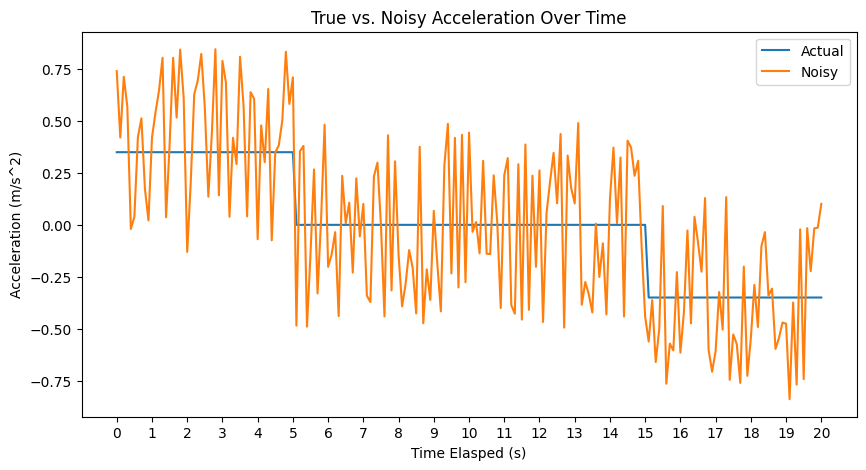

In [ ]:

data = pd.read_csv("ACCELERATION.csv", header=None)

times = list(map(float, list(data[0])[1:]))
accel = list(map(float, list(data[1])[1:]))
noisy_accel = list(map(float, list(data[2])[1:]))

plt.figure(figsize=(10, 5))
plt.plot(times, accel, label="Actual")
plt.plot(times, noisy_accel,label="Noisy")
plt.legend()
plt.xlabel('Time Elasped (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('True vs. Noisy Acceleration Over Time')
plt.xticks(list(range(0,21,1)))
plt.show()

## A single plot showing the speeds that would be obtained using the actual acceleration and the noisy acceleration values respectively.

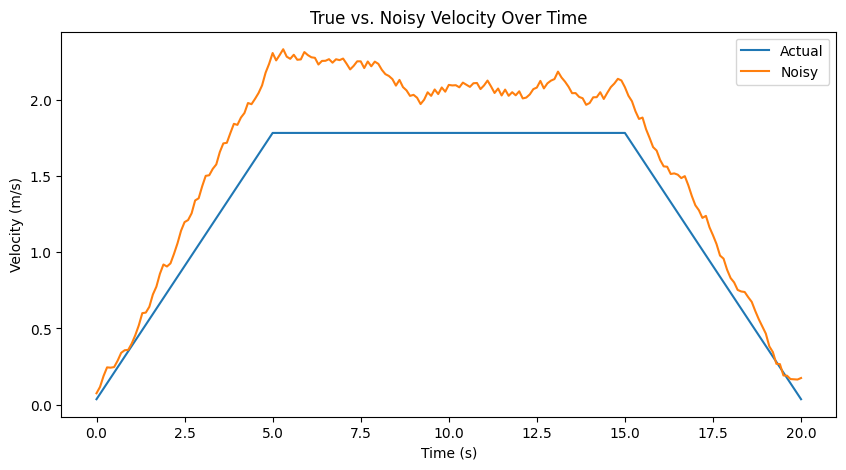

In [ ]:
speed = 0
speeds = []
noisy_speed = 0
noisy_speeds = []
for i in range(len(times)):
  speed = speed + accel[i] * 0.1
  speeds.append(speed)
  noisy_speed = noisy_speed + noisy_accel[i] * 0.1
  noisy_speeds.append(noisy_speed)

plt.figure(figsize =(10, 5))
plt.plot(times, speeds, label = "Actual")
plt.plot(times, noisy_speeds, label = "Noisy")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("True vs. Noisy Velocity Over Time")
plt.show()

## A single plot showing the distance traveled that would be obtained using the actual acceleration and the noisy acceleration values respectively

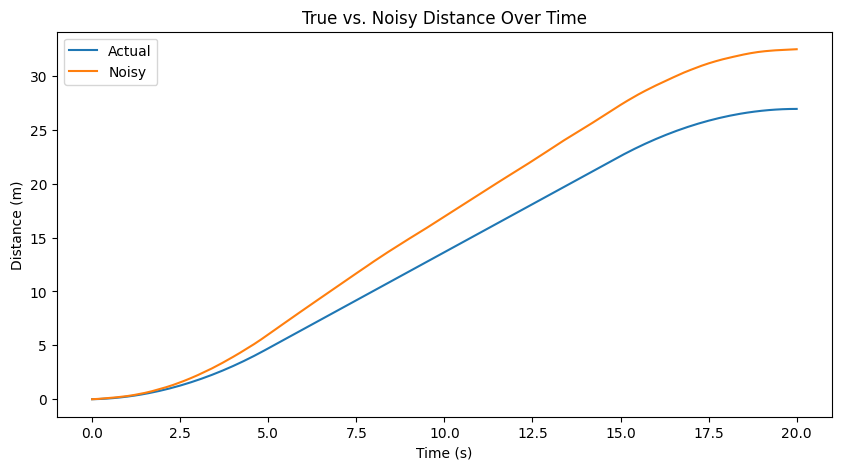

In [ ]:
dist = 0
dists = [0]
noisy_dist = 0
noisy_dists = [0]
for i in range(1, len(speeds)):
  dist = dists[-1] + speeds[i] * 0.1 + 0.5 * accel[i] * 0.01
  dists.append(dist)
  noisy_dist = noisy_dists[-1] + noisy_speeds[i] * 0.1 + 0.5 * noisy_accel[i] * 0.01
  noisy_dists.append(noisy_dist)

plt.figure(figsize =(10, 5))
plt.plot(times, dists, label = "Actual")
plt.plot(times, noisy_dists, label = "Noisy")
plt.xlabel("Time (s)")
plt.ylabel("Distance (m)")
plt.legend()
plt.title("True vs. Noisy Distance Over Time")
plt.show()

## Report the final distances calculated using the two different accelerations.

In [ ]:
print(f"Final Distance (ACTUAL): {dists[-1]}")
print(f"Final Distance (NOISY): {noisy_dists[-1]}")

Final Distance (ACTUAL): 26.949999999999903
Final Distance (NOISY): 32.49094362407502


## What is the difference between the two estimates?

In [ ]:
print(f"Difference: {abs(dists[-1] - noisy_dists[-1])}")

Difference: 5.540943624075119


# Milestone 2 Part 2: Step Detection

## A single figure for each timeseries you choose, showing the raw data and the smoothed data.

Text(0.5, 1.0, 'Smoothed vs. Noisy Acceleration over Time on Accelerometer Z-Axis')

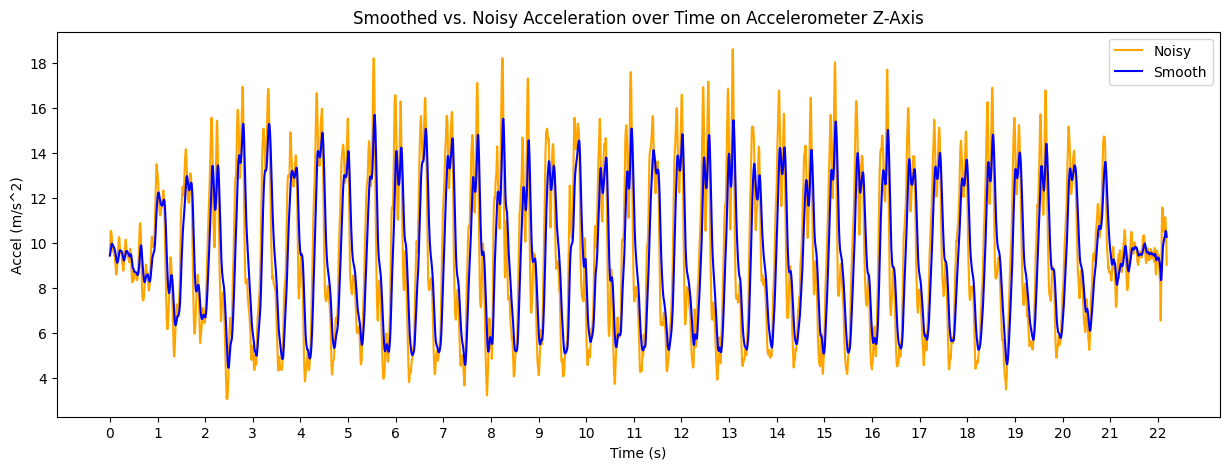

In [ ]:
walking = pd.read_csv("WALKING.csv")
accel_z = []
times = []

z = 0
time = 0

alpha = 0.1

for i in range(len(walking)):
  if i == 0:
    accel_z.append(walking['accel_z'][0])
    times.append(0)
  else:
    z = (accel_z[i-1] * (1-alpha)) + (walking['accel_z'][i] * alpha)
    time = (walking['timestamp'][i] - walking['timestamp'][i-1])/ns2s + times[i-1]
    accel_z.append(z)
    times.append(time)

plt.figure(figsize =(15, 5))
plt.plot(times, walking["accel_z"], label = "Noisy", color = "orange")
plt.plot(times, accel_z, label = "Smooth", color = "blue")
plt.legend()
plt.xticks(ticks = np.arange(0, 23, 1))
plt.xlabel("Time (s)")
plt.ylabel("Accel (m/s^2)")
plt.title("Smoothed vs. Noisy Acceleration over Time on Accelerometer Z-Axis")

# Explanation of Smoothing the Data
For this section, we selected the measurements for the accelerometer's z-axis over time. To smooth the data, we calculated a Exponential Weighted Moving Average with an alpha of 0.1. We input the first smoothed value, $s_0$, to be the same as the raw value, $a_0$. After that, to calculate each subsequential smoothed acceleration point, $s_i$, we multiplied the previously calculated smoothed value $s_{i-1}$ by a weight of 0.9 and added that to the product of the current acceleration $a_i$ and 0.1.

Text(0, 0.5, 'Acceleration (m/s^2)')

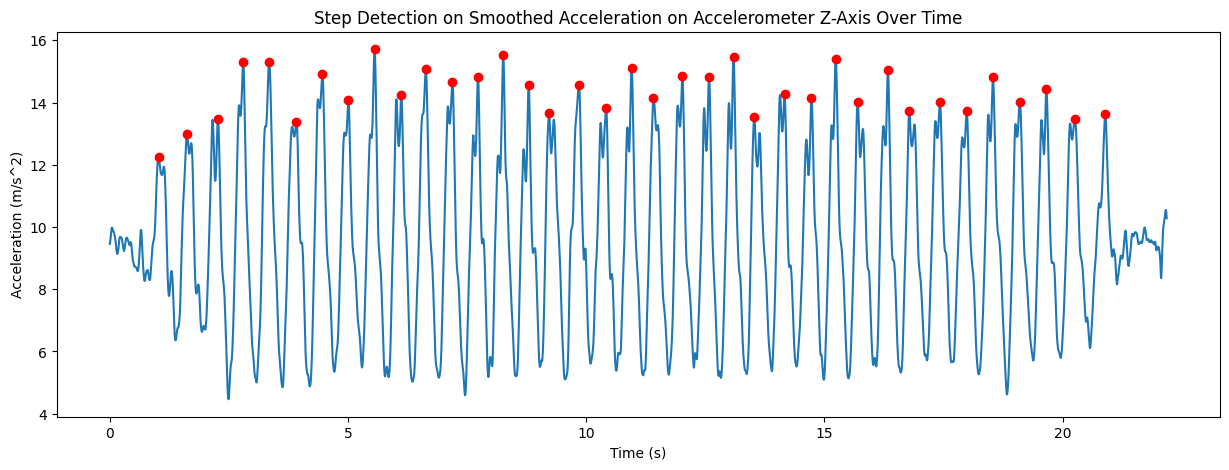

In [ ]:
upper_t = 11 # Upper Threshold that is 1 unit greater than the standard force of gravity (9.8)
lower_t = 9 # Lower Threshold that is 1 unit less than the standard force of gravity
start = -1 # The start index of one potential step window
end = 0 # The end index of one potential step windows
windows = [] # Windows that are found to be a potential step
peaks = [] # Steps


# This for loop checks for pairs of minimums to create a window for where a local maximum (a step) could occur
# Only registers significant minimums BELOW the lower threshold, to avoid complications due to noise
for i in range(1, len(accel_z)-1):
  if accel_z[i] < accel_z[i-1] and accel_z[i] < accel_z[i + 1] and accel_z[i] < lower_t:
    start = end
    end = i
    windows.append( (start, end) )

w_ptr = 0 # The selected window in the list
max = -1 # The max acceleration within a window
time = -1 # The index of the peak within a window

# Step detection algorithm, sliding door-esque
for i in range(1, len(accel_z)-1):
  if w_ptr > len(windows) - 1:
    continue

  start, end = windows[w_ptr]

  # Update current step window and append local max and index if there is a step
  if i > end:
    if max != -1:
      peaks.append( (time, max) )
    w_ptr += 1
    max = -1

  # Calculate the max value of the window
  # Considered a step if GREATER than upper threshold
  else:
    if accel_z[i] > max and accel_z[i] > upper_t:
      max = accel_z[i]
      time = times[i]

peaks = pd.DataFrame(peaks, columns=['time', 'accel'])

plt.figure(figsize =(15, 5))
plt.plot(times, accel_z)
plt.plot(peaks['time'], peaks['accel'], 'ro')
plt.title("Step Detection on Smoothed Acceleration on Accelerometer Z-Axis Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")

# Explanation of Step Detection
For this section, we selected the measurements for the accelerometer's z-axis over time. To detect steps on the smooth data, we established a couple thresholds to indicate the possibility of the start and end of a step and to confirm a step. A lower threshold of 9 was established to show deviation from 9.8 $m/s^2$, the acceleration due to gravity, which would indicate the start of a step cycle. This threshold seemed optimal because it was about 1 unit less than the normal acceleration of gravity and all significant minimums seemed to be less than 9. An upper threshold of 11 was established to indicate the existence or the maximum of a step within a cycle, which seemed optimal because it was at least 1 unit above the normal acceleration of gravity and it seemed as though all the significant peaks were greater than 11.

 To create the windows of step cycles, we iterated over all acceleration values. We declared variables called start and end to denominate the bounds of the window, initialized -1 and 0 respectively. If the current acceleration $a_i$ was a local min (less than $a_{i-1}$ and $a_{i+1}$) AND less than the lower threshold, we mark the start index as the end bound of the previous window, update the end index as the current i and append this as a tuple to the list of windows. This way, we would have pairs of minimums as our bounds for each step cycle.

 To detect a step, we simply calculated the max acceleration value within each of the windows. In the accelerometer, a foot touching the ground could be visualized as a spike in acceleration above the force of gravity, which was the max. To ensure that we only counted steps with no noise interference, we used the upper threshold as another bound to calculate the max. We declared a pointer to reference which window we were on, and two variables to save the max and the index of the max for a given cycle. We iterated through all acceleration values again. We accessed the start and end indexes of the current window to determine whether a step had been found by appending the max acceleration and timestamp to our list and then to reset the max. If a max was not found (-1), we did not append the acceleration and time. To calculate a max within a window, we simply compared the current value to the max and checked if it was larger than the threshold. At the end of a cycle (when i was equal to the end index of the window), we then decided whether or not to add the step to our list and updated the window pointer.

 ## In the end, we detected **37 steps** with this algorithm.


In [ ]:
print(len(peaks))

37


# Part 3: Direction Detection

## Data Preparation

In [ ]:
turning = pd.DataFrame(
    columns=['timestamp', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z']
)

with open('TURNING.csv', 'r') as f:
  for line in f:
    arr = line.strip().split(",")[:10]
    if len(arr) != 10:
      arr = arr[:-1]
      arr.extend(['0.0','0.0','0.0'])
    if arr[0] != 'timestamp':
      turning.loc[len(turning)] = arr

## A single figure for each timeseries you choose, showing the raw data and the smoothed data.

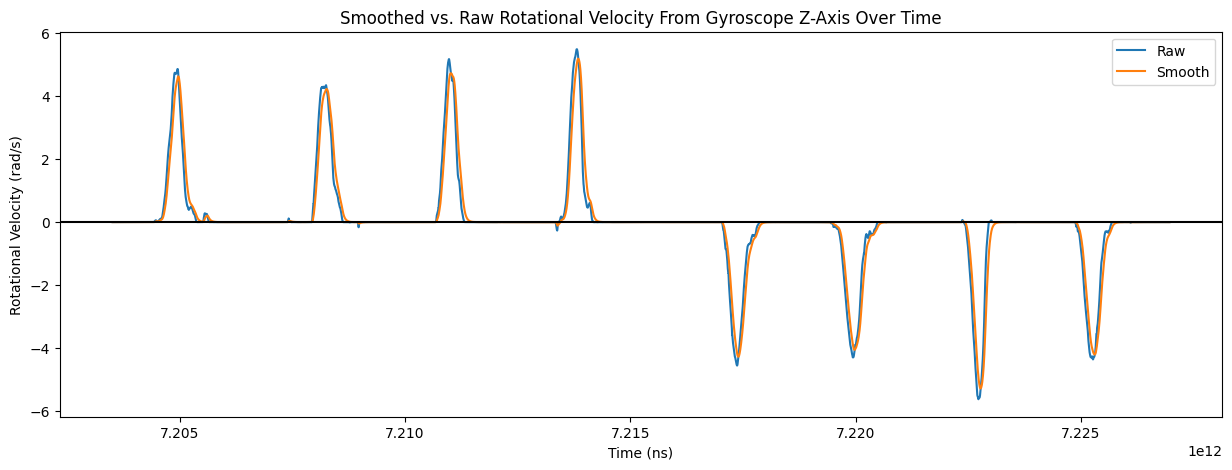

In [ ]:
times = list(map(float, turning['timestamp']))
gyro_z = list(map(float, turning['gyro_z']))

smooth_z = []
alpha = 0.1
z = 0
for i in range(len(gyro_z)):
  if i == 0:
    smooth_z.append(gyro_z[i])
  else:
    z = smooth_z[i-1] * (1-alpha) + gyro_z[i] * alpha
    smooth_z.append(z)


plt.figure(figsize = (15,5))
plt.plot(times, gyro_z, label = "Raw")
plt.plot(times, smooth_z, label = "Smooth")
plt.title("Smoothed vs. Raw Rotational Velocity From Gyroscope Z-Axis Over Time")
plt.xlabel("Time (ns)")
plt.ylabel("Rotational Velocity (rad/s)")
plt.axhline(y = 0, color = "black")
plt.legend()

# Explanation of Smoothing the Data
For this section, we selected the measurements for the gyroscope's z-axis over time. Just like in the Step Detection section, we calculated a EMWA to smooth the data again with an alpha of 0.1. We input the first smoothed value, $s_0$, to be the same as the raw value, $w_0$. After that, to smooth each subsequential smoothed rotational velocity, $s_i$, we multiplied the previously calculated smoothed value $s_{i-1}$ by a weight of 0.9 and added that to the product of the current rotational velocity $w_i$ and 0.1.



Text(0, 0.5, 'Rotational Velocity (rad/s)')

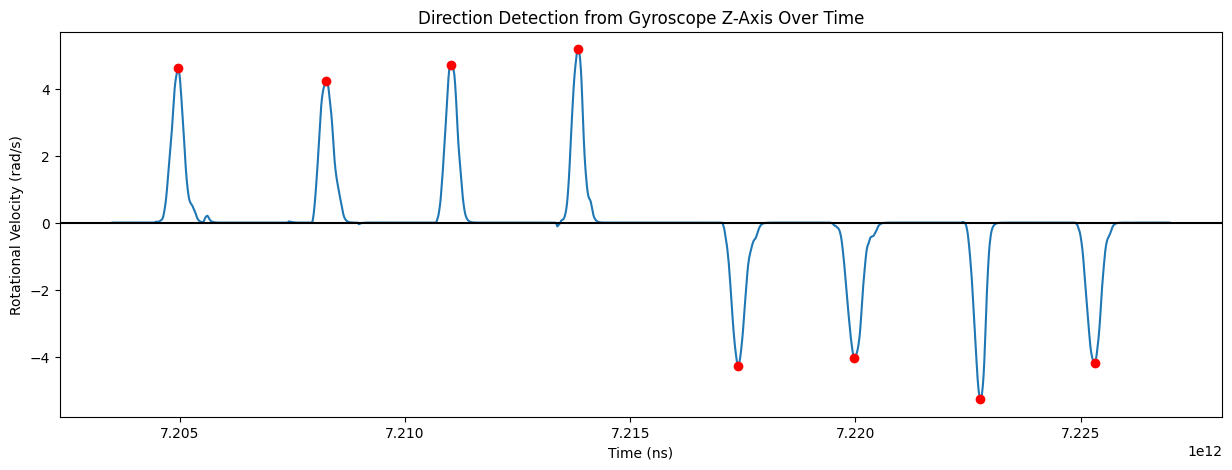

In [ ]:
start = -1 # Start index of a turn
end = -1 # End index of a turn
peak = 0 # Peak of the turn
time = -1 # Index of the peak

turn = False # Whether or not a turn is occurring
turns = []

# The value for a 90 degree turn in radians with some error
# Used to check if a 90 degree turn has happened
angle = 1.45

for i in range(len(smooth_z)):

  # The threshold of 0.5 denominates a change from the usual value of 0 rad/s
  if not turn and abs(smooth_z[i]) > 0.5: # Start of turn
    start = i
    peak = 0
    turn = True

  if turn:

    # Peak rotational velocity of the turn (can be negative or positive)
    if abs(smooth_z[i]) > abs(peak):

      peak = smooth_z[i]
      time = i

    # The threshold of 0.5 here indicates the velocity is returning back to 0
    if abs(smooth_z[i]) < 0.5: # End of turn
      turn = False
      end = i
      estimated_angle = 0

      # Calculate the angle of the turn by integrating for the area under curve
      for j in range(start, end):
        dt = times[j+1] - times[j]
        estimated_angle += (smooth_z[j] + smooth_z[j+1]) / 2 * dt

      estimated_angle /= ns2s

      # Check if angle is greater or equal to about 90 degrees
      if abs(estimated_angle) >= angle:
        turns.append( (times[time], peak))

turns = pd.DataFrame(turns, columns = ['time', 'max'])

plt.figure(figsize = (15,5))
plt.plot(times, smooth_z)
plt.plot(turns['time'], turns['max'], 'ro')
plt.title("Direction Detection from Gyroscope Z-Axis Over Time")
plt.xlabel("Time (ns)")
plt.axhline(y = 0, color = "black")
plt.ylabel("Rotational Velocity (rad/s)")

# Direction Detection Algorithm

For this section, we selected the measurements for the accelerometer's z-axis over time. After smoothing the data, we iterate over the measurements recorded by the gyroscope. We were informed that the data first experienced four clockwise 90 degree turns and then four counterclockwise, so we can assume that a positive peak in rotational velocity is a clockwise turn.

To create windows of turns, similar to in the step detection, we declared a start and end variable, as well as peak and time variable to keep track of the maximum value and its index within the window. This time we also included a boolean turn to determine if a turn was in progress. To determine if a 90 degree turn had been taken, we also stored the value 1.45 radians, which is around 83 degrees, to allow for some margin of error. A final threshold we included was +-0.5, which indicate a deviation from the normal velocity of 0 and therefore the start or end of a turn.

To calculate the turns, we iterated over the smoothed data. If a turn was not in progress and there was a value greater in magnitude than 0.5, we recorded the index as the start of the turn and reset the peak value to 0, also marking that there was a turn. When a turn was in progress, we simply kept track of the maximum of the window until it returned back to 0.5, where we would then indicate the turn was done and would calculate the rotational displacement it had experienced. To calculate this rotational displacement, we integrated under the curve. From the start index to the end index, we found the area of all pairs of sequential entries, summing together iterations of the formula: $d=z_j+z_{j+1} * (t_{j+1} - t_j)$/2 and also converted it from nanoseconds to seconds if necessary. Finally, if the value was greater than the 1.45 radians from before, we added it to our list of 90 degree turns.

## In the end, we found 8 turns. The first four were approximately 90 degrees clockwise and the last four were 90 degrees counterclockwise.

In [ ]:
print(f"Number of turns found: {len(turns)}")
print(f"Angles of turns (rad): {list(turns['angle']/ns2s)}")

Number of turns found: 8
Angles of turns (rad): [1.478240098861486, 1.523230330425027, 1.5060215248861861, 1.5316299069061365, -1.4658731641267955, -1.5043021281365878, -1.4940670374283602, -1.483625585057548]


# Part 4: Trajectory Plotting

## Data Preparation

### This portion utilizes the Step Detection Algorithm seen before.

Text(0, 0.5, 'Acceleration (m/s^2)')

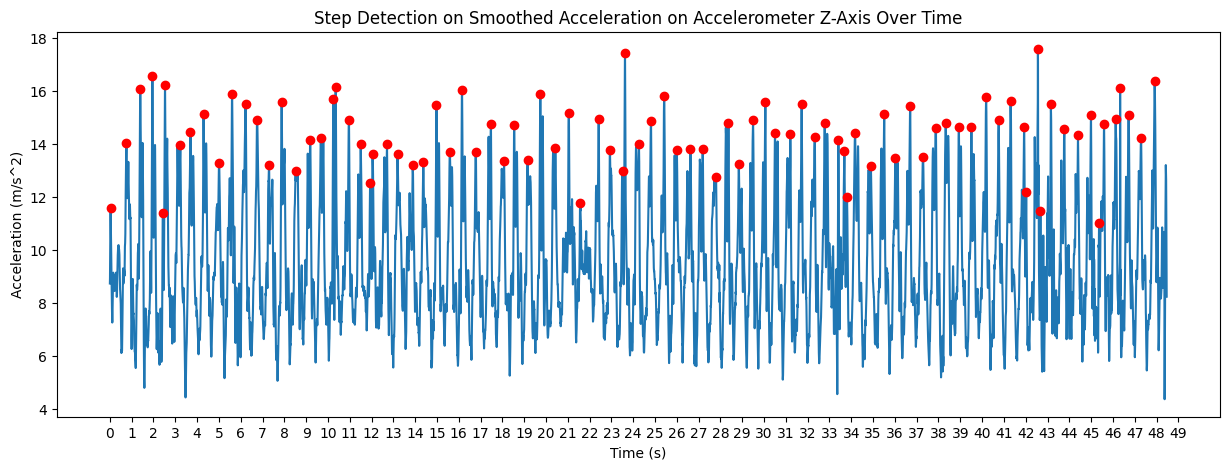

In [ ]:
walk_and_turn = pd.read_csv("WALKING_AND_TURNING.csv")
times = list(map(float, walk_and_turn['timestamp']))
start = times.pop(0) / ns2s
times.append(start - start)
for i in range(len(walk_and_turn) - 1):
  val = times.pop(0)
  times.append(val  / ns2s- start)
accel_z = list(map(float, walk_and_turn['accel_z']))
gyro_z = list(map(float, walk_and_turn['gyro_z']))

upper_t = 11
lower_t = 9
start = -1
end = 0
windows = []
peaks = []
idx = -1

for i in range(1, len(accel_z)-1):
  if accel_z[i] < accel_z[i-1] and accel_z[i] < accel_z[i + 1] and accel_z[i] < lower_t:
    start = end
    end = i
    windows.append( (start, end) )

w_ptr = 0
max = -1
time = -1
for i in range(1, len(accel_z)-1):
  if w_ptr > len(windows) - 1:
    continue

  start, end = windows[w_ptr]

  if i > end:
    if max != -1:
      peaks.append( (idx, time, max) )
    w_ptr += 1
    max = -1
  else:
    if accel_z[i] > max and accel_z[i] > upper_t:
      max = accel_z[i]
      time = times[i]
      idx = i

peaks = pd.DataFrame(peaks, columns=['index', 'time', 'accel'])

plt.figure(figsize = (15,5))
plt.xticks(ticks = np.arange(0, 50, 1))
plt.plot(times, accel_z)
plt.plot(peaks['time'], peaks['accel'], 'ro')
plt.title("Step Detection on Smoothed Acceleration on Accelerometer Z-Axis Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")

### This portion utilizes the Direction Detection Algorithm seen before.

Text(0, 0.5, 'Rotational Velocity (rad/s)')

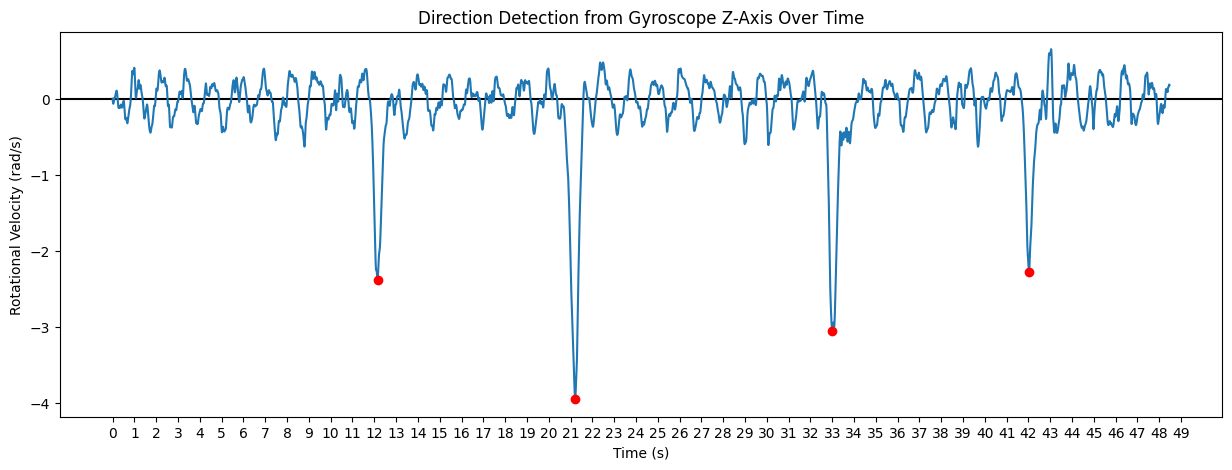

In [ ]:
smooth_z = []
alpha = 0.1
z = 0
for i in range(len(gyro_z)):
  if i == 0:
    smooth_z.append(gyro_z[i])
  else:
    z = smooth_z[i-1] * (1-alpha) + gyro_z[i] * alpha
    smooth_z.append(z)

start = -1
end = -1
peak = 0
time = -1

turn = False
turns = []

angle = 0.65

for i in range(len(smooth_z)):

  if not turn and abs(smooth_z[i]) > 0.5: # Start of turn

    start = i
    peak = 0
    turn = True

  if turn:

    if abs(smooth_z[i]) > abs(peak):

      peak = smooth_z[i]
      time = i

    if abs(smooth_z[i]) < 0.5: # End of turn

      turn = False
      end = i
      estimated_angle = 0
      for j in range(start, end):
        dt = times[j+1] - times[j]
        estimated_angle += (smooth_z[j] + smooth_z[j+1]) / 2 * dt

      if abs(estimated_angle) >= angle:
        turns.append( (time, times[time], peak, estimated_angle, times[start], times[end]))

turns = pd.DataFrame(turns, columns = ['index', 'time', 'max', 'angle', 'start', 'end'])
plt.figure(figsize = (15,5))
plt.axhline(y = 0, color = "black")

plt.plot(times, smooth_z, label = "Smooth")
plt.plot(turns['time'], turns['max'], 'ro')
plt.xticks(ticks = np.arange(0, 50, 1))
plt.title("Direction Detection from Gyroscope Z-Axis Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Rotational Velocity (rad/s)")

### This step combines the measurements from the two algorithms to provide the number of steps and direction throughout the path.

In [ ]:
steps = []
steps.append( (0, 1.57) )
turns_values = turns['index'].values
peaks_values = peaks['index'].values
step = 0
angle = 1.57

for i in range(len(walk_and_turn)):
  if i in turns_values:
    angle -= turns.loc[turns['index'] == i]['angle'].iloc[0]
  if i in peaks_values:
    step += 1
    steps.append( (step, angle) )

steps = pd.DataFrame(steps, columns = ['step', 'angle'])


In [ ]:
import math

x_coords = [0]
y_coords = [0]

angles = steps['angle'].values

for angle in angles:
  x_new = x_coords[-1] + math.cos(angle)
  y_new = y_coords[-1] + math.sin(angle)
  x_coords.append(x_new)
  y_coords.append(y_new)


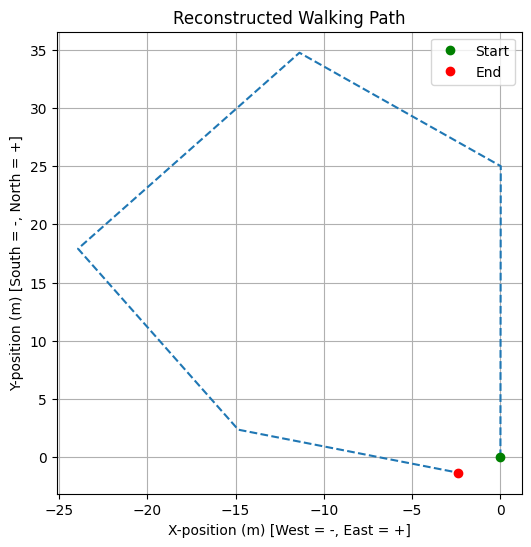

In [ ]:
plt.figure(figsize = (6,6))
plt.plot(x_coords, y_coords,linestyle = '--')
plt.title("Reconstructed Walking Path")
plt.xlabel("X-position (m) [West = -, East = +]")
plt.ylabel("Y-position (m) [South = -, North = +]")
plt.plot(x_coords[0], y_coords[0], "o", label = "Start", color = "Green")
plt.plot(x_coords[-1], y_coords[-1], "o", label = "End", color = "Red")
plt.legend()
plt.grid()

In [ ]:
print(steps.groupby('angle').size())

angle
1.570000    25
2.434362    15
4.072299    21
5.240923    18
5.994759    13
dtype: int64


# Distances Covered and Turning Angles
The device first starts north at an angle of 1.57 radians and walks 25 meters. Then, it turns approximately 45 degrees counterclockwise and continues walking 15 meters at an angle of 2.43 radians. It then turns approximately 90 degrees counterclockwise and continues walking 21 meters at an angle of 4.07 radians. Then it takes another approximately 90 degree angle counterclockwise (maybe closer to 67 degrees) and continues for 18 meters at an angle of 5.24 radians. Finally, it takes another 45 degree angle clockwise and continues for 13 meters at an angle of 5.99 radians.

# Explanation of Methods Used

To get the data necessary for plotting, we used the **step detection** and **direction detection** algorithms as described before. Once we had these values, starting at an initial value of 1.57 radians to start due north, we iterated through the entirety of the device's recordings to document how each step corresponded with an angle. For each timestamp that matched to a step in our list, we would increment the steps taken and append the current step and angle to a list, suggesting a 1m advancement in whatever the angle was. For each timestamp that matched to a change in angle on our list, we simply subtracted the value of the change from our angle, given that radians measures counterclockwise as positive, but our gyroscope measured counterclockwise as negative.

Finally, to convert these measurements (step number and angle) to linear coordinates, we iterated through the lists to calculate x and y coordinates. Starting from (0,0), we simply added the cosine of the current angle to the previously computed x value and the sine of the current angle to the previously computed y value, as all steps were 1 meter long. With this completed, we had our traversal path in pairs of x and y coordinates and then plotted the above graph.